# Trialing One At A Time Sensitivity Analysis to the OGGM

We will now apply OAT Sensitivity Analysis to our scalar mass balance calibration technique to see which parameters are most sensitive. This does not include SAFE directly but follows a similar technique to that from the Hydrological example of SAFE's section on OAT Sensitivity Analysis.

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.stats as st

import oggm
from oggm import cfg, utils, workflow
from oggm.sandbox.edu import run_constant_climate_with_bias
from oggm.core.massbalance import mb_calibration_from_scalar_mb, apparent_mb_from_any_mb
from oggm.core import massbalance
from oggm.utils._funcs import rmsd
from oggm import tasks

# Install python package for interactive visualisation and import required functions:
!pip install -q ipywidgets
from ipywidgets import interact, FloatRangeSlider, IntRangeSlider

# Install SAFE package and import required functions
!pip install SAFEpython

import safepython

import xarray as xr
import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
import safepython.RSA_thres as RSA_tr # Module that implements RSA
import safepython.plot_functions as pf # Module to visualize the results
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling, AAT_sampling_extend # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping
from safepython.util import empiricalcdf
from safepython.util import RMSE

In [2]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2026-01-08 14:48:00: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-01-08 14:48:00: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-01-08 14:48:00: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-01-08 14:48:01: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-01-08 14:48:01: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-01-08 14:48:01: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [3]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2026-01-08 14:48:02: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-01-08 14:48:02: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


# 1 - One-at-a-time Sensitivity Analysis

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

We cannot compare the runoff specifically to observed runoff since the OGGM does not contain this data.

In [25]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oat_oggm_runner(sample_row):
    
    # Set the parameter values that are being sampled
    melt_f, prcp_fac, temp_bias = sample_row

    # Running the model with the given parameters (without calibration which would alter them again)
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=float(melt_f), prcp_fac=float(prcp_fac), temp_bias=float(temp_bias)) # Monthly TI model
    fls = gdir_hef.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance

    # In-situ mass balance for comparison
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    # Calculate the goodness-of-fit metrics
    mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))

    return mbdf['mod_mb'], mean_diff, std_diff, rmsd_


We will now plot our results, the parameter values can be changed one-at-a-time via a toggle on the graph below.

Note that not every combination of parameters will work here - some will lead to model crashes.

In [26]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_function(melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    mb,_,_, _ = oat_oggm_runner(param)

    # Plot the results
    plt.figure(figsize=[15,3])
    plt.plot(mb, label='sim', color='k')
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
    plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], label='obs')
    plt.ylabel('Specific mass balance (mm w.e.)')
    plt.xlabel('Year')
    plt.legend()
    plt.show();

# Create interactive plot, the toggles will change the parameter values 
interact(oat_function,
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));



interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

# GSA - Global Sensitvity Analysis

In [93]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oggm_runner(sample_row):

    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)
    
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=melt_f, prcp_fac=prcp_fac, temp_bias=temp_bias)
    fls = gdir_hef.read_pickle('inversion_flowlines')
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    # mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    # std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    # rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))

    return np.array([mbdf['mod_mb']])


In [ ]:
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

def oggm_runner(sample_row):

    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)
    
    mbmod = massbalance.MonthlyTIModel(gdir_hef, melt_f=melt_f, prcp_fac=prcp_fac, temp_bias=temp_bias)
    fls = gdir_hef.read_pickle('inversion_flowlines')
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)



    return np.array([mean_diff, std_diff, rmsd_]), mbdf['mod_mb']


### Running Monte Carlo Simulations

In [107]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
distr_fun = st.uniform
x_min = np.array([1.5, 0.1, -15.0])
x_max = np.array([17.0, 10.0, 15.0])

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
samp_strat = 'lhs' 
N = 2000
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N)

QQ  = model_execution(oggm_runner, X)

mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))

YY = np.nan * np.ones((N, 3))

for i, x in enumerate(QQ):
    YY[i,0] = x.mean() - mbdf['in_situ_mb'].mean()
    YY[i,1] = x.std() - mbdf['in_situ_mb'].std()
    YY[i,2] = rmsd(x, mbdf['in_situ_mb'])

YY[:,0]
YY[:,1]

2026-01-08 16:35:57: oggm.cfg: PARAMS['melt_f'] changed from `4.435064677620231` to `16.498534612520437`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['prcp_fac'] changed from `9.101470077485201` to `7.179740050725278`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['temp_bias'] changed from `-10.221402028458186` to `-4.1617837660694725`.


2026-01-08 16:35:57: oggm.cfg: PARAMS['melt_f'] changed from `16.498534612520437` to `13.039543148708638`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['prcp_fac'] changed from `7.179740050725278` to `5.496015025282649`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['temp_bias'] changed from `-4.1617837660694725` to `14.66011774817687`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['melt_f'] changed from `13.039543148708638` to `8.533496660330224`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['prcp_fac'] changed from `5.496015025282649` to `9.518554807567899`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['temp_bias'] changed from `14.66011774817687` to `-14.977525864859757`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['melt_f'] changed from `8.533496660330224` to `15.044978811781437`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['prcp_fac'] changed from `9.518554807567899` to `4.666794149010117`.
2026-01-08 16:35:57: oggm.cfg: PARAMS['temp_bias'] changed from `-14.977525864859757` to `-11.021484136519282`.
2026-01-08 16:35:57: oggm.cf

array([ 549.74409255, 1863.86657502,  484.71515162, ...,  424.47883797,
        392.61966348,   57.40362223])

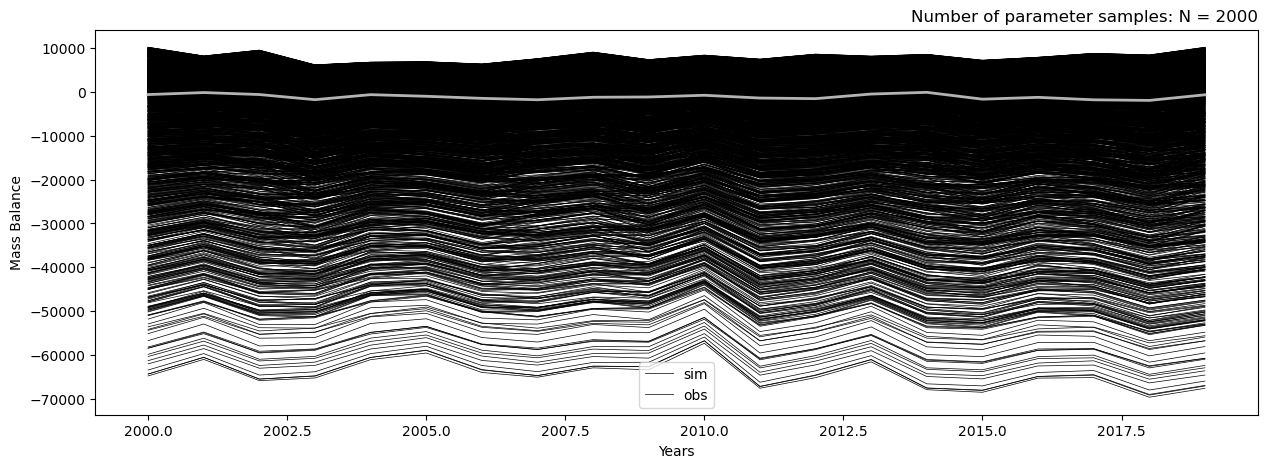

In [108]:
# Plot Monte Carlo (MC) simulations results and compare with data:
plt.figure(figsize=[15,5])
plt.plot(mbdf['in_situ_mb'].index.values, np.transpose(QQ), 'k', linewidth = 0.5)
plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], linewidth=2)
plt.ylabel('Mass Balance'); plt.xlabel('Years')
plt.legend(['sim', 'obs'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

### Scatter plot of the fit-to-data metrics

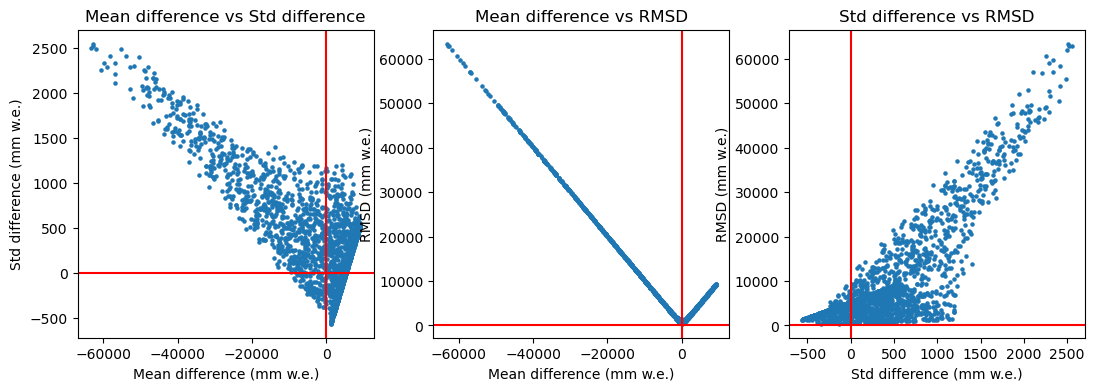

In [110]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY[:,0], YY[:,1], s=5), plt.title('Mean difference vs Std difference'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('Std difference (mm w.e.)'),
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')

plt.subplot(1,3,2), plt.scatter(YY[:,0], YY[:,2], s=5), plt.title('Mean difference vs RMSD'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')

plt.subplot(1,3,3), plt.scatter(YY[:,1], YY[:,2], s=5), plt.title('Std difference vs RMSD'), plt.xlabel('Std difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')

plt.show()

# The red lines show the target of having zero differences in the mean, standard deviation and RMSD.
# TODO: Would absolute differences be better than the raw ones?

### Distribution of the model outputs

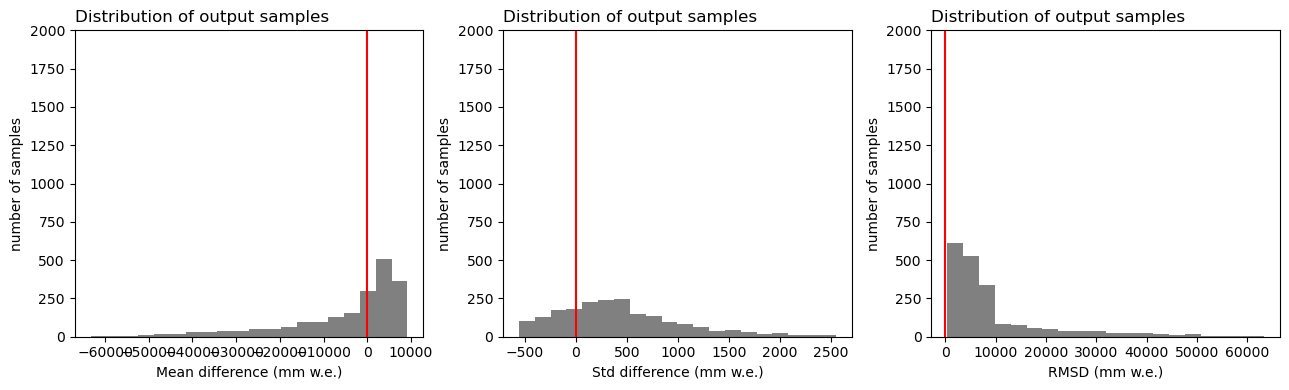

In [111]:
Y_Labels = ['Mean difference (mm w.e.)', 'Std difference (mm w.e.)', 'RMSD (mm w.e.)', 'Mean & Std difference jointly']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,0], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,1], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[1])

plt.subplot(1,3,3), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,2], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[2])

plt.tight_layout()

# Calculating the sensitivity indices

Now we use the input-output samples generated in the previous step to calculate sensitivity indices using **Regional Sensitivity Analysis**. Calculating 3 sets of indices, each measuring the relative importance of the 3 input parameters.

TODO: Concatenate targets together?

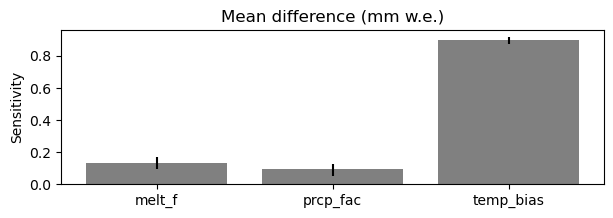

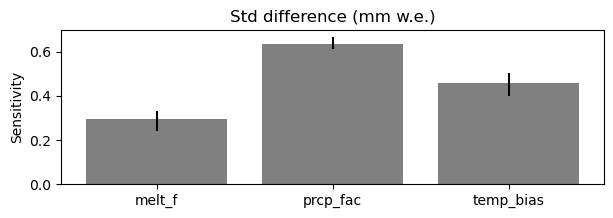

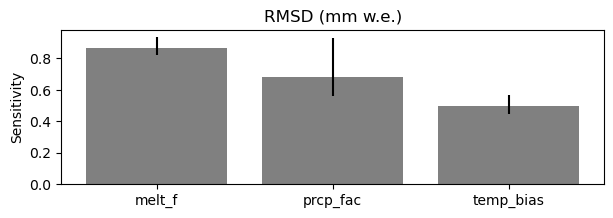

In [118]:
Nboot = 50 # Number of resamples used for bootstrapping

for i in range(3):
    if i==0:
        Y=YY[:,0]
        target=0
    if i==1:
        Y=YY[:,1]
        target=0
    if i==2:
        Y = YY[:,2]
        target = 500 # RMSD cannot be zero here? Minimum working number is around 500, minimum observed value is around 400.

    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()